In [4]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

PROJECT_ROOT = Path("..")
DATA_DIR = PROJECT_ROOT / "data" / "processed"
RESULTS_DIR = PROJECT_ROOT / "results" / "interpretation"
FIG_DIR = PROJECT_ROOT / "figures" / "interpretation"
MODEL_DIR = PROJECT_ROOT / "models"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

features_path = DATA_DIR / "supermarket_price_direction_features_h1_t05.parquet"
model_path = MODEL_DIR / "xgboost_balanced_sample_h1_t05.joblib"

df = pd.read_parquet(features_path)
model = joblib.load(model_path)

df.shape

(8711346, 28)

In [5]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

PROJECT_ROOT = Path("..")
DATA_DIR = PROJECT_ROOT / "data" / "processed"
RESULTS_DIR = PROJECT_ROOT / "results" / "interpretation"
FIG_DIR = PROJECT_ROOT / "figures" / "interpretation"
MODEL_DIR = PROJECT_ROOT / "models"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

features_path = DATA_DIR / "supermarket_price_direction_features_h1_t05.parquet"
model_path = MODEL_DIR / "xgboost_balanced_sample_h1_t05.joblib"

print("Feature file exists:", features_path.exists())
print("Model file exists:", model_path.exists())

df = pd.read_parquet(features_path)
model = joblib.load(model_path)

df.shape

Feature file exists: True
Model file exists: True


(8711346, 28)

In [6]:
target_col = "target_direction_h1_t05"

id_cols = ["product_id", "date"]

feature_cols = [
    col for col in df.columns
    if col not in id_cols + [target_col]
]

feature_cols

['price',
 'days_since_previous_capture',
 'price_lag_1',
 'price_lag_2',
 'price_lag_3',
 'price_change_pct_lag_1',
 'price_change_pct_lag_2',
 'rolling_price_mean_3',
 'rolling_price_std_3',
 'rolling_price_mean_7',
 'rolling_price_std_7',
 'price_vs_rolling_mean_3_pct',
 'price_vs_rolling_mean_7_pct',
 'price_changed_lag_1',
 'price_changed_lag_2',
 'recent_change_count_3',
 'recent_change_count_7',
 'days_since_last_change',
 'dayofweek',
 'weekofyear',
 'month',
 'day',
 'retailer',
 'category',
 'own_brand_flag']

In [7]:
train_end = pd.Timestamp("2024-03-10")
val_end = pd.Timestamp("2024-03-24")

train_df = df[df["date"] <= train_end].copy()

val_df = df[
    (df["date"] > train_end) &
    (df["date"] <= val_end)
].copy()

test_df = df[df["date"] > val_end].copy()

train_df.shape, val_df.shape, test_df.shape

((5765174, 28), (1030166, 28), (1916006, 28))

In [8]:
categorical_cols = [
    "retailer",
    "category",
    "own_brand_flag",
]

for col in categorical_cols:
    train_df[col] = train_df[col].astype("category")
    val_df[col] = val_df[col].astype("category")
    test_df[col] = test_df[col].astype("category")

    val_df[col] = val_df[col].cat.set_categories(train_df[col].cat.categories)
    test_df[col] = test_df[col].cat.set_categories(train_df[col].cat.categories)

    train_df[col] = train_df[col].cat.codes
    val_df[col] = val_df[col].cat.codes
    test_df[col] = test_df[col].cat.codes

In [9]:
label_map = {
    "Down": 0,
    "Stable": 1,
    "Up": 2,
}

inverse_label_map = {
    0: "Down",
    1: "Stable",
    2: "Up",
}

X_test = test_df[feature_cols].copy()
y_test = test_df[target_col].map(label_map).astype("int8")

X_test.shape, y_test.shape

((1916006, 25), (1916006,))

In [10]:
target_col = "target_direction_h1_t05"

id_cols = ["product_id", "date"]

feature_cols = [
    col for col in df.columns
    if col not in id_cols + [target_col]
]

train_end = pd.Timestamp("2024-03-10")
val_end = pd.Timestamp("2024-03-24")

train_df = df[df["date"] <= train_end].copy()

val_df = df[
    (df["date"] > train_end) &
    (df["date"] <= val_end)
].copy()

test_df = df[df["date"] > val_end].copy()

train_df.shape, val_df.shape, test_df.shape

((5765174, 28), (1030166, 28), (1916006, 28))

In [11]:
categorical_cols = [
    "retailer",
    "category",
    "own_brand_flag",
]

for col in categorical_cols:
    train_df[col] = train_df[col].astype("category")
    val_df[col] = val_df[col].astype("category")
    test_df[col] = test_df[col].astype("category")

    val_df[col] = val_df[col].cat.set_categories(train_df[col].cat.categories)
    test_df[col] = test_df[col].cat.set_categories(train_df[col].cat.categories)

    train_df[col] = train_df[col].cat.codes
    val_df[col] = val_df[col].cat.codes
    test_df[col] = test_df[col].cat.codes

In [12]:
label_map = {
    "Down": 0,
    "Stable": 1,
    "Up": 2,
}

inverse_label_map = {
    0: "Down",
    1: "Stable",
    2: "Up",
}

X_test = test_df[feature_cols].copy()
y_test = test_df[target_col].map(label_map).astype("int8")

X_test.shape, y_test.shape

((1916006, 25), (1916006,))

In [13]:
X_test.shape, y_test.shape

((1916006, 25), (1916006,))

In [14]:
feature_importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

feature_importance

,feature,importance
18,dayofweek,0.110860
11,price_vs_rolling_mean_3_pct,0.108506
12,price_vs_rolling_mean_7_pct,0.098588
13,price_changed_lag_1,0.083457
22,retailer,0.077371
16,recent_change_count_7,0.070113
17,days_since_last_change,0.067186
0,price,0.039602
24,own_brand_flag,0.038473
21,day,0.036179


In [15]:
feature_importance.to_csv(
    RESULTS_DIR / "xgboost_feature_importance.csv",
    index=False
)

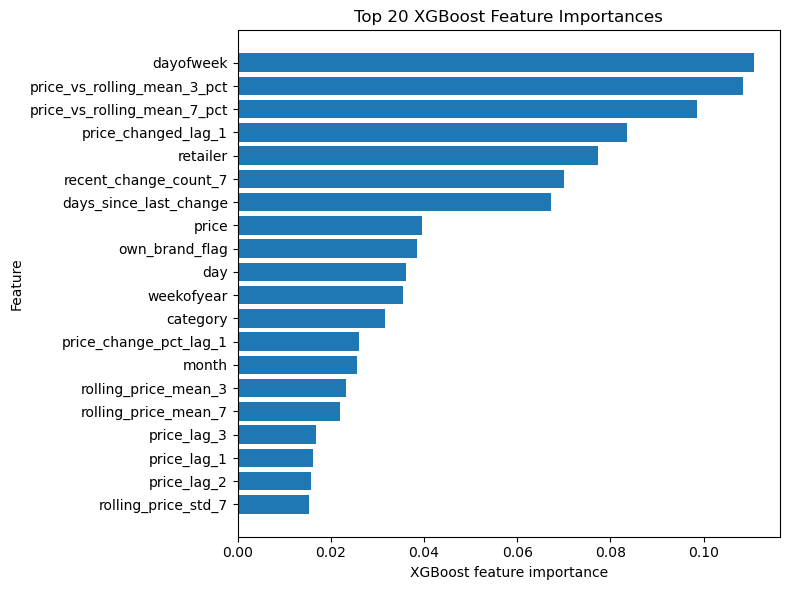

In [16]:
top_importance = feature_importance.head(20).sort_values("importance")

plt.figure(figsize=(8, 6))
plt.barh(top_importance["feature"], top_importance["importance"])
plt.xlabel("XGBoost feature importance")
plt.ylabel("Feature")
plt.title("Top 20 XGBoost Feature Importances")
plt.tight_layout()
plt.savefig(FIG_DIR / "xgboost_top20_feature_importance.png", dpi=300)
plt.show()

In [17]:
y_test_pred = model.predict(X_test)

test_metrics = {
    "model": "xgboost_balanced_sample",
    "split": "test",
    "accuracy": accuracy_score(y_test, y_test_pred),
    "balanced_accuracy": balanced_accuracy_score(y_test, y_test_pred),
    "macro_f1": f1_score(y_test, y_test_pred, average="macro"),
    "weighted_f1": f1_score(y_test, y_test_pred, average="weighted"),
}

test_metrics

{'model': 'xgboost_balanced_sample',
 'split': 'test',
 'accuracy': 0.8501393001900829,
 'balanced_accuracy': 0.6095720279889244,
 'macro_f1': 0.3652066958207416,
 'weighted_f1': 0.9072711359679605}

In [18]:
test_report = classification_report(
    y_test,
    y_test_pred,
    labels=[0, 1, 2],
    target_names=["Down", "Stable", "Up"],
    output_dict=True,
    zero_division=0
)

test_report_df = pd.DataFrame(test_report).T
test_report_df

,precision,recall,f1-score,support
Down,0.045869,0.470303,0.083587,1.464800e+04
Stable,0.994368,0.855725,0.919852,1.887035e+06
Up,0.050744,0.502688,0.092182,1.432300e+04
accuracy,0.850139,0.850139,0.850139,8.501393e-01
macro avg,0.363660,0.609572,0.365207,1.916006e+06
weighted avg,0.980063,0.850139,0.907271,1.916006e+06


In [19]:
test_cm = confusion_matrix(
    y_test,
    y_test_pred,
    labels=[0, 1, 2]
)

test_cm_df = pd.DataFrame(
    test_cm,
    index=["Actual_Down", "Actual_Stable", "Actual_Up"],
    columns=["Pred_Down", "Pred_Stable", "Pred_Up"]
)

test_cm_df

,Pred_Down,Pred_Stable,Pred_Up
Actual_Down,6889,4779,2980
Actual_Stable,140542,1614783,131710
Actual_Up,2756,4367,7200


In [ ]:
pd.DataFrame([test_metrics]).to_csv(
    RESULTS_DIR / "xgboost_test_metrics_recomputed.csv",
    index=False
)

test_report_df.to_csv(
    RESULTS_DIR / "xgboost_test_classification_report_recomputed.csv"
)

test_cm_df.to_csv(
    RESULTS_DIR / "xgboost_test_confusion_matrix_recomputed.csv"
)